In [5]:
import numpy as np
import numpyro.distributions as dist
import numpyro
numpyro.set_host_device_count(2)
from numpyro import infer
import jax
import jax.numpy as jnp
from jax import random
print(jax.local_device_count())
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

# first, step zero here, lets import the data
import pandas as pd
df = pd.read_csv('../../../../hub_data_share/gaiadr3_solar_neighborhood.csv')

# select only stars with parallax over 40
nearby_sel = df.parallax > 40
nearby_df = df[nearby_sel]

# remove white dwarfs
wd_color = (-0.4, 2)
wd_mg = (10, 16.5)

wd_sel = ((nearby_df.bp_rp > wd_color[0]) & (nearby_df.bp_rp < wd_color[1]) & (nearby_df.mg > wd_mg[0]) & (nearby_df.mg < wd_mg[1]))

nearby_nowd_df = nearby_df[~wd_sel]

def plot_data():
    # plt.errorbar(color, mag, yerr=σ, fmt=",k", ms=0, capsize=0, lw=1)
    plt.scatter(color, mag, marker="o", s=5, c="teal", label="data")
    plt.xlabel('BP-RP')
    plt.ylabel('Mag')
    plt.gca().invert_yaxis()

mag = jnp.array(nearby_nowd_df.mg.values)
color = jnp.array(nearby_nowd_df.bp_rp.values)

2


In [6]:

# create new model
def quad_model(color=None, mag=None):
    # priors
    a = numpyro.sample('a', dist.Normal(scale=100))
    b = numpyro.sample('b', dist.Normal(scale=100))
    c = numpyro.sample('c', dist.Normal(scale=100))

    σ = numpyro.sample('scatter', dist.HalfNormal(scale=20))

    # Define the mean of the normal likelihood
    μ = numpyro.deterministic("μ",  a*color**2 + b*color + c) 

    # Likelihood (sampling distribution) of observations
    with numpyro.plate("data", len(color)):
        obs = numpyro.sample('mag', dist.Normal(loc=μ, scale=σ), obs=mag)
        

rng_key = random.PRNGKey(36)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(quad_model)
num_samples = 5000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         color=color,
         mag=mag)

mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a     -0.30      0.01     -0.30     -0.31     -0.29   2609.54      1.00
         b      4.40      0.03      4.40      4.35      4.45   2438.48      1.00
         c      1.06      0.04      1.06      1.00      1.12   2611.98      1.00
   scatter      0.44      0.00      0.44      0.44      0.45   4184.18      1.00

Number of divergences: 0


Text(0.5, 1.0, 'with random samples from the chain')

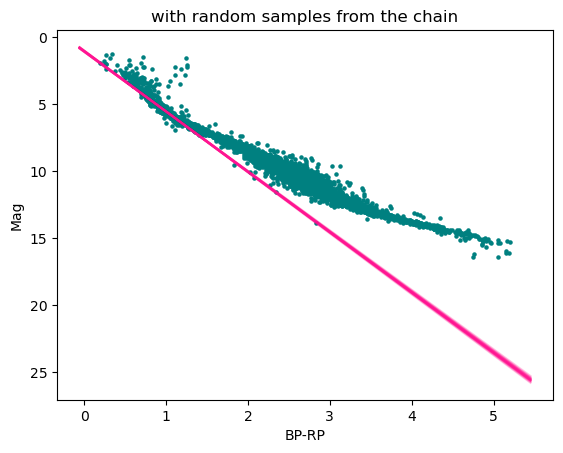

In [7]:
plot_data()
samples = mcmc.get_samples()
xlow, xhigh = plt.xlim()
x = jnp.linspace(xlow, xhigh, 100)


for i in random.choice(rng_key, num_samples, (50,)):
    mu = x * samples['a'][i]**2 + x * samples['b'][i] + samples['c'][i]
    plt.plot(x, mu, color='deeppink', alpha=0.1);
plt.title('with random samples from the chain')